**[🏠 Course Home](00_START_HERE.ipynb) | ↩️ Return to: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb)**

---

# 📐 Appendix: Understanding the Hessian Matrix & Jacobian
### *From Everyday Analogies to Newton's Optimization and Bayesian Uncertainty*

---

## 1. What is the Hessian Matrix? (Forget the Jargon!)
In high school calculus, you learned:
- **1st Derivative ($f'$)**: The slope.
- **2nd Derivative ($f''$)**: How the slope bends.
  - $f'' > 0$ $\implies$ Bends **UP** like a smile 😊 $\smile$ (You are at a **bottom / minimum**).
  - $f'' < 0$ $\implies$ Bends **DOWN** like a frown ☹️ $\frown$ (You are at a **top / maximum**).

### What happens when you have more than 1 variable (e.g., $x$ and $y$)?
On a 2D surface, you can walk in **infinite directions** (North, South, East, West, North-East...). 
You can't describe the curvature with just one number anymore. You need a **grid of numbers** that tracks how the ground bends in every possible direction: **that grid is the Hessian Matrix ($H$)**.

### The Formal Mathematical Definition
For a twice-differentiable scalar function of $n$ variables $f(x_1, x_2, \dots, x_n)$, the **Hessian matrix** $\mathbf{H}$ (or $\nabla^2 f$) is the square $n \times n$ matrix of second-order partial derivatives:

$$\mathbf{H}(f) = \begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_1 \partial x_n} \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots & \frac{\partial^2 f}{\partial x_2 \partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial^2 f}{\partial x_n \partial x_1} & \frac{\partial^2 f}{\partial x_n \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_n^2}
\end{bmatrix}, \quad H_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$$

For a 2D surface $f(x, y)$ (e.g., elevation over an $(x, y)$ plane):
$$\mathbf{H}(f) = \begin{bmatrix}
f_{xx} & f_{xy} \\
f_{yx} & f_{yy}
\end{bmatrix} = \begin{bmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2}
\end{bmatrix}$$

- **Diagonal elements ($f_{xx}, f_{yy}$)**: The pure curvature along the $x$-axis and $y$-axis.
- **Off-diagonal elements ($f_{xy}, f_{yx}$)**: The "twist" or cross-curvature (how the slope along $x$ changes as you move along $y$).
- **Symmetry (Schwarz's / Clairaut's Theorem)**: For smooth functions, the order of differentiation does not matter ($\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial^2 f}{\partial y \partial x}$). Thus, **the Hessian is always a symmetric matrix** ($\mathbf{H} = \mathbf{H}^T$), which guarantees that all its eigenvalues are real numbers!

---

## 2. Demystifying the Math Terms: What does "Definite" Mean?

Mathematicians love intimidating words, but the concepts are trivial:

| Term | What it actually means | The Shape | What critical point is it? |
| :--- | :--- | :--- | :--- |
| **Positive Definite** | **"Curves UP in EVERY direction"** (All smiles 😊) | 🥣 **A Cereal Bowl** | **Local Minimum** (a marble settles at the bottom) |
| **Negative Definite** | **"Curves DOWN in EVERY direction"** (All frowns ☹️) | 🪂 **A Dome / Umbrella** | **Local Maximum** (a marble rolls away in all directions) |
| **Indefinite** | **"Curves UP in some directions, DOWN in others"** (Mixed smile & frown) | 🥔 **A Pringle / Horse Saddle** | **Saddle Point** (it's a minimum along one axis, maximum along another) |
| **Semi-definite** | **"Curves up/down in some directions, completely FLAT in others"** | 🛹 **A Skate Halfpipe / Trench** | **A Valley / Ridge of multiple minima** |

That's literally all "positive definite" means: **it smiles in every direction**.


---
## 3. The 3 Intuitive Analogies

### 🏔️ Analogy 1: Fog on a Mountain
Imagine you are blindfolded on a landscape. You test your footing:
1. You feel the slope with your cane: **it is completely flat right here** ($\nabla f = 0$).
2. Now you take a tiny step North, South, East, and West:
   - If every single step goes **uphill**, you are sitting in a crater or bowl (**Positive Definite**).
   - If every single step goes **downhill**, you are standing on a peak (**Negative Definite**).
   - If North/South goes uphill, but East/West drops downhill, you are sitting on a mountain pass (**Indefinite**).

### 🥔 Analogy 2: The Bowl, the Dome, and the Pringle
- **Bowl**: Drop a marble anywhere, it rolls to the center. (Pure positive curvature).
- **Dome**: Place a marble on top, any slight push sends it falling away. (Pure negative curvature).
- **Pringle**: A marble placed in the center will stay trapped along the U-curve, but roll off the sides along the inverted-U curve. (Mixed curvature).

### 🏎️ Analogy 3: The Car and the Steering Wheel
- **Speed**: How fast your position is changing (1st derivative).
- **G-Force / Acceleration**: How the road is twisting into a banked curve (2nd derivative / Hessian). The steeper the bank, the higher the curvature.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries imported successfully!")


Libraries imported successfully!


---
## 3. Visualizing Canonical Curvatures & Eigenvalues

The behavior of a critical point ($\nabla f = 0$) is determined by the **eigenvalues** of the Hessian:
- **$\lambda_1 > 0, \lambda_2 > 0$**: Positive Definite $\implies$ **Local Minimum**
- **$\lambda_1 < 0, \lambda_2 < 0$**: Negative Definite $\implies$ **Local Maximum**
- **$\lambda_1 \cdot \lambda_2 < 0$**: Indefinite $\implies$ **Saddle Point**

Let's generate 3D surfaces and contour plots for all three cases side-by-side.


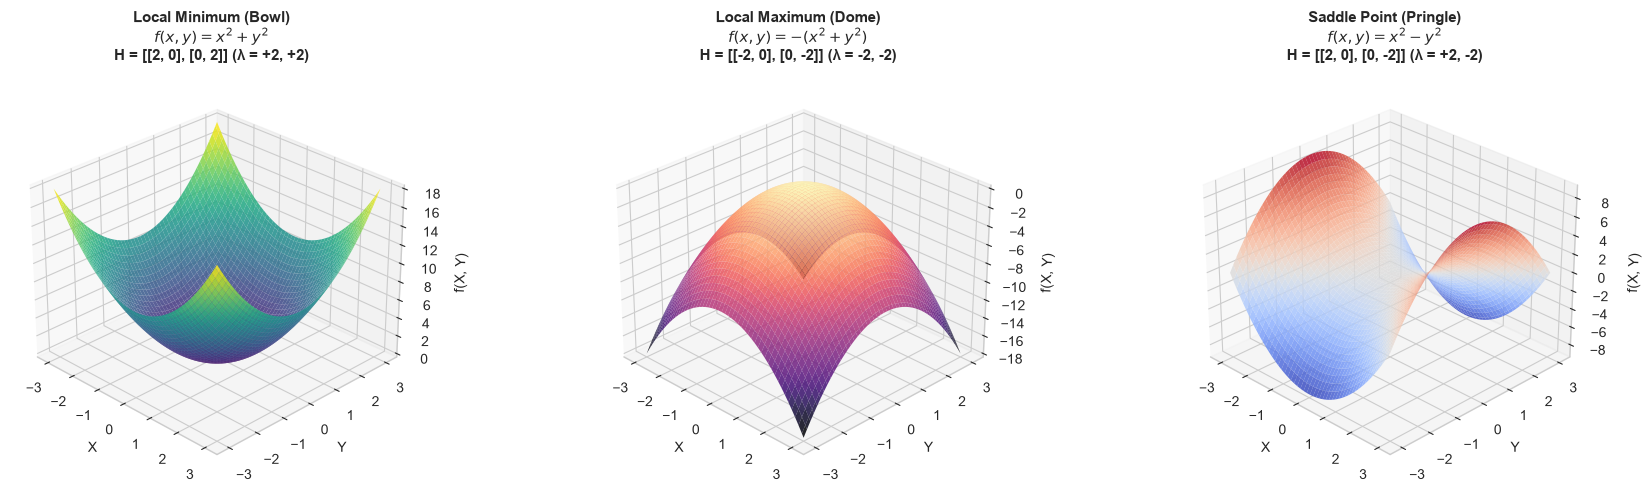

In [2]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# Three canonical surfaces
surfaces = [
    ("Local Minimum (Bowl)\n" + r"$f(x,y) = x^2 + y^2$" + "\nH = [[2, 0], [0, 2]] (λ = +2, +2)", X**2 + Y**2, 'viridis'),
    ("Local Maximum (Dome)\n" + r"$f(x,y) = -(x^2 + y^2)$" + "\nH = [[-2, 0], [0, -2]] (λ = -2, -2)", -(X**2 + Y**2), 'magma'),
    ("Saddle Point (Pringle)\n" + r"$f(x,y) = x^2 - y^2$" + "\nH = [[2, 0], [0, -2]] (λ = +2, -2)", X**2 - Y**2, 'coolwarm')
]

fig = plt.figure(figsize=(18, 5))

for i, (title, Z, cmap) in enumerate(surfaces, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap=cmap, alpha=0.85, edgecolor='none')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('f(X, Y)')
    ax.view_init(elev=28, azim=-45)

plt.tight_layout()
plt.show()


---
## 4. What About the Jacobian? (And How It Connects to the Hessian)

### The Missing Piece: Multiple Outputs!
Notice the pattern of calculus:
- **1 input $\to$ 1 output** ($y = f(x)$): The slope is a single number $f'(x)$.
- **Multiple inputs $\to$ 1 output** ($z = f(x, y)$): The slope is a vector: **Gradient ($\nabla f$)**.
- **Multiple inputs $\to$ MULTIPLE outputs** ($\mathbf{f}(x, y) = [u(x, y), v(x, y)]$): The slope is a matrix: **Jacobian ($J$)**.

The **Jacobian** answers: *"If I nudge each input variable by a tiny amount, how does **every single output variable** respond?"*

```
                 ┌                                           ┐
                 │  ∂f₁/∂x₁     ∂f₁/∂x₂   ...   ∂f₁/∂xₙ     │  ← How Output 1 responds to all inputs
                 │  ∂f₂/∂x₁     ∂f₂/∂x₂   ...   ∂f₂/∂xₙ     │  ← How Output 2 responds to all inputs
   J(f)(x)    =  │    ⋮            ⋮       ⋱       ⋮        │
                 │  ∂fₘ/∂x₁     ∂fₘ/∂x₂   ...   ∂fₘ/∂xₙ     │  ← How Output m responds to all inputs
                 └                                           ┘
```
Each **row** of the Jacobian is simply the **gradient of one output**!

---

### Two Intuitive Analogies for the Jacobian

#### 🤖 1. The Robotic Arm (Inputs: Joint Angles $\to$ Outputs: Coordinates in Space)
Think of a factory robotic arm with two pivot joints ($\theta_1$ and $\theta_2$):
- **Inputs**: The 2 motor angles $[\theta_1, \theta_2]$.
- **Outputs**: The 2D coordinates $[x, y]$ of the gripper claw.

When motor 1 turns at $5^\circ/\text{sec}$, the claw moves across both $x$ and $y$.  
The **Jacobian matrix** translates motor speeds directly into claw velocity:
$$\begin{bmatrix} \Delta x \\ \Delta y \end{bmatrix} = \mathbf{J} \begin{bmatrix} \Delta \theta_1 \\ \Delta \theta_2 \end{bmatrix}$$

#### 🎈 2. Stretching a Rubber Sheet (Transformation & Area Scaling)
Imagine a grid of squares drawn on a sheet of rubber. Grab the sheet and stretch, twist, and pull it:
- Each little square deforms into a tilted parallelogram.
- The **Jacobian matrix** at any coordinate captures the local stretch, shear, and rotation.
- The **Determinant $\det(J)$** tells you the **area magnification factor**:
  - If $\det(J) = 2.5$, that tiny square grew to $2.5\times$ its original size.
  - If $\det(J) < 0$, the rubber sheet was flipped inside out (reflection)!

---

### 💡 The Grand Connection: The Hessian IS the Jacobian of the Gradient!
Here is how they are intimately connected:
1. Start with a scalar function $f(x, y)$ (e.g. elevation).
2. Take the first derivatives to get the **Gradient**: $\nabla f = \left[ \frac{\partial f}{\partial x}, \; \frac{\partial f}{\partial y} \right]$.
   - Notice that the gradient takes 2 inputs $(x, y)$ and produces **2 outputs**!
3. Now, take the **Jacobian** of this gradient vector:
   $$\mathbf{H} = J(\nabla f)$$

**The Hessian is nothing more than the Jacobian of the gradient!**


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
C:\Users\tarob\AppData\Local\Temp\ipykernel_31920\2345852386.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax_trans.set_title("Transformed Space $(u, v) = \mathbf{f}(x, y)$\n(Stretched by Jacobian Matrix)", fontsize=11, fontweight='bold')


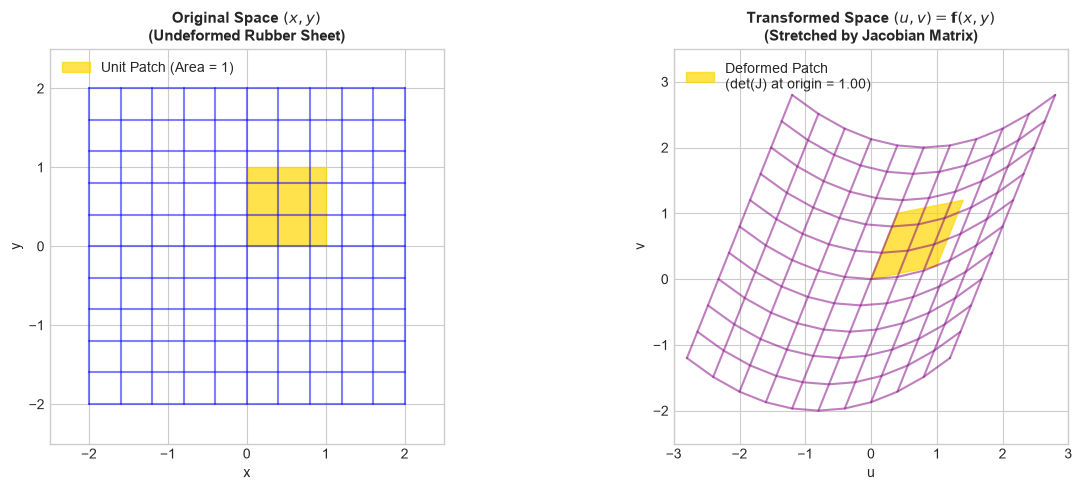

In [3]:
# Visualizing a 2D coordinate transformation and its Jacobian
# Mapping: u(x, y) = x + 0.4*y,  v(x, y) = 0.3*x**2 + y
def transform(x, y):
    u = x + 0.4 * y
    v = 0.2 * x**2 + y
    return u, v

# Jacobian of this mapping:
# [ [∂u/∂x, ∂u/∂y],  =  [ [1.0, 0.4],
#   [∂v/∂x, ∂v/∂y] ]      [0.4*x, 1.0] ]
def jacobian_det(x, y):
    return (1.0 * 1.0) - (0.4 * 0.4 * x)

# Create a regular grid
grid_x, grid_y = np.meshgrid(np.linspace(-2, 2, 11), np.linspace(-2, 2, 11))
u_grid, v_grid = transform(grid_x, grid_y)

fig, (ax_orig, ax_trans) = plt.subplots(1, 2, figsize=(13, 5))

# Plot Original Grid
for i in range(grid_x.shape[0]):
    ax_orig.plot(grid_x[i, :], grid_y[i, :], 'b-', alpha=0.5)
    ax_orig.plot(grid_x[:, i], grid_y[:, i], 'b-', alpha=0.5)
ax_orig.set_title("Original Space $(x, y)$\n(Undeformed Rubber Sheet)", fontsize=11, fontweight='bold')
ax_orig.set_xlabel("x")
ax_orig.set_ylabel("y")
ax_orig.set_xlim(-2.5, 2.5)
ax_orig.set_ylim(-2.5, 2.5)
ax_orig.set_aspect('equal')

# Highlight a unit square at (0, 0)
square_x = np.array([0, 1, 1, 0, 0])
square_y = np.array([0, 0, 1, 1, 0])
ax_orig.fill(square_x, square_y, color='gold', alpha=0.7, label='Unit Patch (Area = 1)')
ax_orig.legend(loc='upper left')

# Plot Deformed Grid
for i in range(grid_x.shape[0]):
    ax_trans.plot(u_grid[i, :], v_grid[i, :], 'purple', alpha=0.5)
    ax_trans.plot(u_grid[:, i], v_grid[:, i], 'purple', alpha=0.5)

# Transformed square
sq_u, sq_v = transform(square_x, square_y)
ax_trans.fill(sq_u, sq_v, color='gold', alpha=0.7, label=f'Deformed Patch\n(det(J) at origin = {jacobian_det(0, 0):.2f})')
ax_trans.set_title("Transformed Space $(u, v) = \mathbf{f}(x, y)$\n(Stretched by Jacobian Matrix)", fontsize=11, fontweight='bold')
ax_trans.set_xlabel("u")
ax_trans.set_ylabel("v")
ax_trans.set_xlim(-3, 3)
ax_trans.set_ylim(-2.5, 3.5)
ax_trans.set_aspect('equal')
ax_trans.legend(loc='upper left')

plt.tight_layout()
plt.show()


---
## 5. Symbolic Calculus with SymPy: Proving $H(f) = J(\nabla f)$

Let's use SymPy to analytically calculate the Gradient, Jacobian, and Hessian for:
$$f(x, y) = x^3 - 3xy^2 + y^3$$
And verify that the **Jacobian of the Gradient vector** is identical to the **Hessian matrix**!


In [4]:
# Define symbols
x_sym, y_sym = sp.symbols('x y', real=True)

# Define function
f_sym = x_sym**3 - 3*x_sym*y_sym**2 + y_sym**3
print(f"Function f(x, y) = {f_sym}")

# 1. Gradient: ∇f = [∂f/∂x, ∂f/∂y]
grad_f = sp.Matrix([sp.diff(f_sym, x_sym), sp.diff(f_sym, y_sym)])
print("\n1. Gradient Vector ∇f (takes 2 inputs -> returns 2 outputs):")
sp.pprint(grad_f)

# 2. Jacobian of the Gradient Vector: J(∇f)
jacobian_of_grad = grad_f.jacobian([x_sym, y_sym])
print("\n2. Jacobian of the Gradient Matrix J(∇f):")
sp.pprint(jacobian_of_grad)

# 3. Standard Hessian Matrix: H(f)
hessian_f = sp.hessian(f_sym, (x_sym, y_sym))
print("\n3. Standard Hessian Matrix H(f):")
sp.pprint(hessian_f)

# 4. Prove they are mathematically identical!
assert jacobian_of_grad == hessian_f
print("\n✅ Verification Confirmed: J(∇f) == H(f) is EXACTLY TRUE!")


Function f(x, y) = x**3 - 3*x*y**2 + y**3

1. Gradient Vector ∇f (takes 2 inputs -> returns 2 outputs):
⎡    2      2 ⎤
⎢ 3⋅x  - 3⋅y  ⎥
⎢             ⎥
⎢            2⎥
⎣-6⋅x⋅y + 3⋅y ⎦

2. Jacobian of the Gradient Matrix J(∇f):
⎡6⋅x      -6⋅y   ⎤
⎢                ⎥
⎣-6⋅y  -6⋅x + 6⋅y⎦

3. Standard Hessian Matrix H(f):
⎡6⋅x      -6⋅y   ⎤
⎢                ⎥
⎣-6⋅y  -6⋅x + 6⋅y⎦

✅ Verification Confirmed: J(∇f) == H(f) is EXACTLY TRUE!


---
## 6. Application 1: Optimization (Gradient Descent vs. Newton's Method)

### Why Gradient Descent Struggles in Narrow Ravines
Standard Gradient Descent takes steps proportional to the negative gradient:
$$x_{t+1} = x_t - \alpha \nabla f(x_t)$$
The gradient is orthogonal to contour lines. In a narrow, elongated valley (anisotropic curvature where one eigenvalue is huge and the other is tiny), the gradient points almost perpendicularly across the valley walls rather than along the gentle path to the minimum. This causes **severe oscillations (zig-zagging)**!

### How the Hessian Rescales the Universe: Newton's Method
Newton's method approximates $f$ around the current point using a 2nd-order Taylor expansion:
$$f(x + \Delta x) \approx f(x) + \nabla f(x)^T \Delta x + \frac{1}{2} \Delta x^T H \Delta x$$
Setting the derivative with respect to $\Delta x$ to zero gives the **Newton step**:
$$\Delta x = - H^{-1} \nabla f(x)$$

$H^{-1}$ acts as a **preconditioner**:
1. It **de-correlates** the coordinates by rotating into the principal curvature directions (eigenvectors).
2. It **scales** each step inversely by the curvature ($1/\lambda_i$). Steep directions get small steps; flat directions get large steps.
3. For any quadratic function, **Newton's method jumps to the exact minimum in exactly ONE step!**


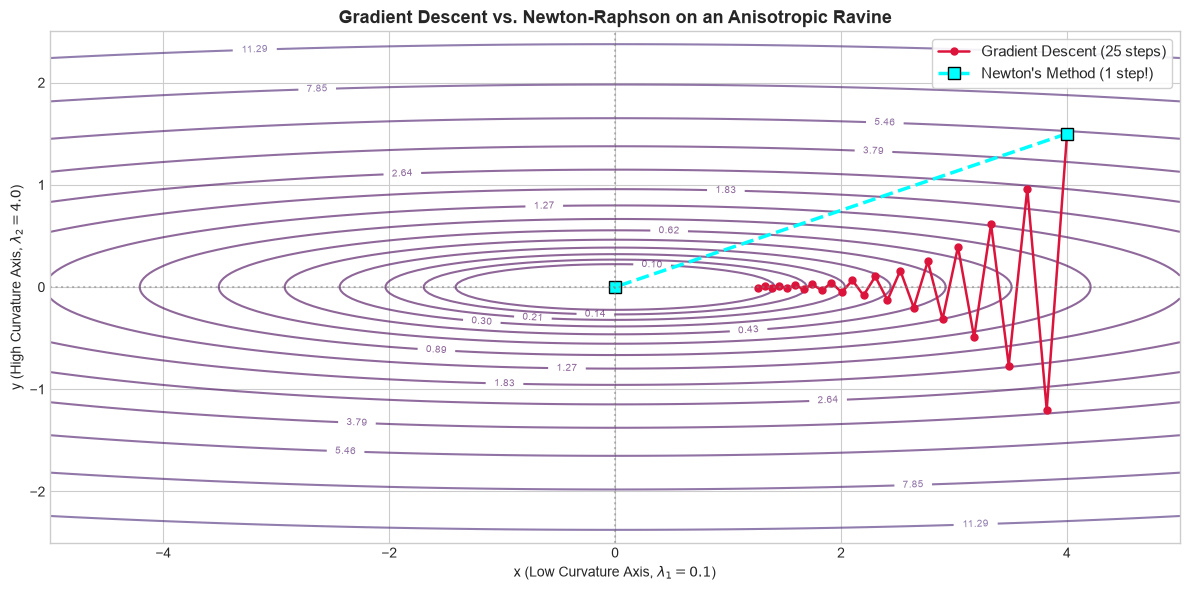

In [5]:
# Define an ill-conditioned quadratic bowl: f(x, y) = 0.05 * x^2 + 2.0 * y^2
# Curvature along X is 0.1 (very flat), curvature along Y is 4.0 (very steep)
def f_quad(x, y):
    return 0.05 * x**2 + 2.0 * y**2

def grad_quad(x, y):
    return np.array([0.1 * x, 4.0 * y])

def hessian_quad(x, y):
    return np.array([[0.1, 0.0],
                     [0.0, 4.0]])

# 1. Gradient Descent Simulation
start_pt = np.array([4.0, 1.5])
lr = 0.45  # If lr > 0.5, GD diverges along Y!
gd_path = [start_pt.copy()]
curr = start_pt.copy()

for _ in range(25):
    curr = curr - lr * grad_quad(curr[0], curr[1])
    gd_path.append(curr.copy())

gd_path = np.array(gd_path)

# 2. Newton's Method Simulation
newton_path = [start_pt.copy()]
H = hessian_quad(start_pt[0], start_pt[1])
H_inv = np.linalg.inv(H)
newton_step = start_pt - H_inv @ grad_quad(start_pt[0], start_pt[1])
newton_path.append(newton_step)
newton_path = np.array(newton_path)

# Plot Comparison
x_vals = np.linspace(-5, 5, 200)
y_vals = np.linspace(-2.5, 2.5, 200)
X_g, Y_g = np.meshgrid(x_vals, y_vals)
Z_g = f_quad(X_g, Y_g)

plt.figure(figsize=(12, 6))
contours = plt.contour(X_g, Y_g, Z_g, levels=np.logspace(-1, 2, 20), cmap='viridis', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=7)

# Plot GD Path
plt.plot(gd_path[:, 0], gd_path[:, 1], 'o-', color='crimson', label=f'Gradient Descent ({len(gd_path)-1} steps)', lw=1.8, markersize=5)

# Plot Newton Path
plt.plot(newton_path[:, 0], newton_path[:, 1], 's--', color='cyan', label="Newton's Method (1 step!)", lw=2.5, markersize=8, markeredgecolor='black')

plt.title("Gradient Descent vs. Newton-Raphson on an Anisotropic Ravine", fontsize=13, fontweight='bold')
plt.xlabel("x (Low Curvature Axis, $\\lambda_1 = 0.1$)")
plt.ylabel("y (High Curvature Axis, $\\lambda_2 = 4.0$)")
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.axvline(0, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


---
## 7. Application 2: Bayesian Statistics & Uncertainty (Laplace Approximation)

In Bayesian statistics and Maximum Likelihood Estimation (MLE):
- Finding the peak of the log-posterior or log-likelihood gives the **Maximum A Posteriori (MAP)** or **MLE** estimate $\hat{\theta}$.
- But how confident are we in that estimate?

### The Hessian as the Precision Matrix
The curvature at the peak tells us how sharply the likelihood drops off:
- **Sharp, narrow peak** $\implies$ High curvature $\implies$ Large Hessian eigenvalues $\implies$ **High certainty / Low variance**.
- **Broad, flat plateau** $\implies$ Low curvature $\implies$ Small Hessian eigenvalues $\implies$ **High uncertainty / High variance**.

Under the **Laplace Approximation**, the posterior distribution is approximated as a Gaussian:
$$\mathcal{N}\left(\hat{\theta}, \,\Sigma\right) \quad \text{where} \quad \Sigma = H^{-1} = \left(-\nabla^2 \ln p(\theta | \mathcal{D})\right)^{-1}$$

**The Hessian of the negative log-posterior is directly the Fisher Information / Precision matrix!**


> [!NOTE]
> **Curriculum Connection**: This inverse-curvature relationship $\Sigma = H^{-1}$ forms the core engine of **[Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb)**, where an optimizer sprints to $\hat{\theta}_{\text{MAP}}$ and numerically extracts the Hessian to immediately construct the parameter covariance matrix.

C:\Users\tarob\AppData\Local\Temp\ipykernel_31920\1687490246.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\tarob\AppData\Local\Temp\ipykernel_31920\1687490246.py:49: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\tarob\.jupyter_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\tarob\.jupyter_env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


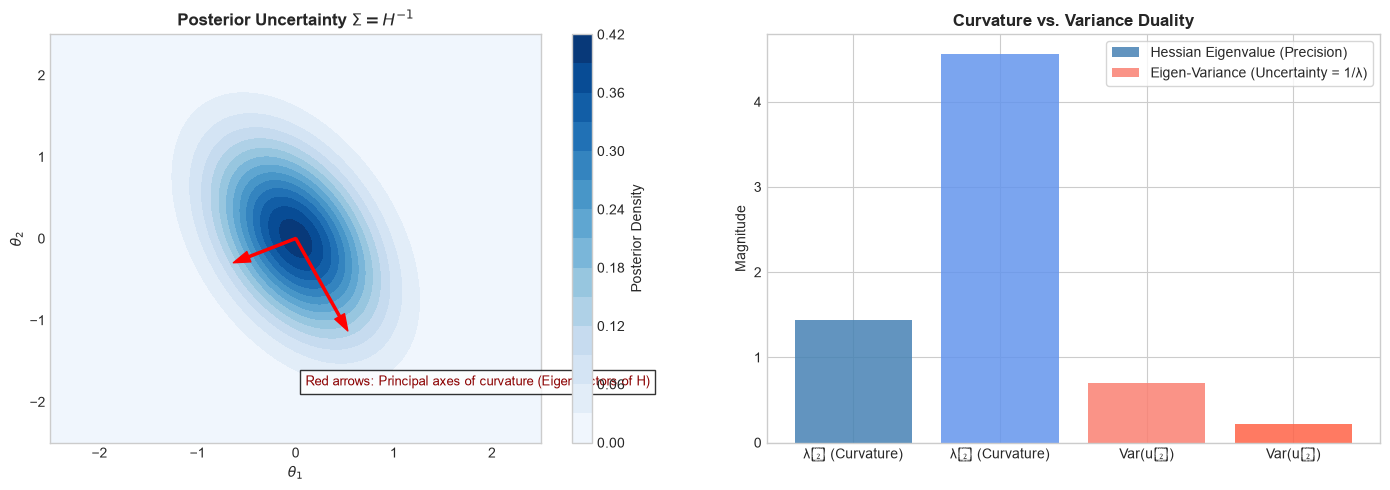

In [6]:
# Illustrating Curvature vs. Parameter Uncertainty
from scipy.stats import multivariate_normal

# Covariance matrix derived from inverse Hessian
# High precision along theta_1, moderate along theta_2 (correlated)
H_neg_log_lik = np.array([
    [4.0, 1.2],
    [1.2, 2.0]
])

# Covariance = H^{-1}
Sigma = np.linalg.inv(H_neg_log_lik)
mean = [0, 0]

# Generate Gaussian contours
theta1 = np.linspace(-2.5, 2.5, 200)
theta2 = np.linspace(-2.5, 2.5, 200)
T1, T2 = np.meshgrid(theta1, theta2)
pos = np.dstack((T1, T2))
rv = multivariate_normal(mean, Sigma)
Z_bayes = rv.pdf(pos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Posterior Contours
c1 = ax1.contourf(T1, T2, Z_bayes, levels=15, cmap='Blues')
plt.colorbar(c1, ax=ax1, label='Posterior Density')
ax1.set_title(r"Posterior Uncertainty $\Sigma = H^{-1}$", fontsize=12, fontweight='bold')
ax1.set_xlabel(r"$\theta_1$")
ax1.set_ylabel(r"$\theta_2$")

# Eigenvectors of Hessian (Principal axes of curvature)
w, v = np.linalg.eigh(H_neg_log_lik)
for i in range(2):
    # Vector scaled inversely by sqrt(eigenvalue) shows confidence interval
    vec = v[:, i] / np.sqrt(w[i]) * 1.5
    ax1.annotate('', xy=(vec[0], vec[1]), xytext=(0, 0),
                 arrowprops=dict(facecolor='red', edgecolor='red', width=1.5, headwidth=8))
ax1.text(0.1, -1.8, "Red arrows: Principal axes of curvature (Eigenvectors of H)", color='darkred', fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

# Bar plot of Eigenvalues vs. Variances
variances = 1.0 / w
ax2.bar(["λ₁ (Curvature)", "λ₂ (Curvature)"], w, color=['steelblue', 'cornflowerblue'], alpha=0.85, label='Hessian Eigenvalue (Precision)')
ax2.bar(["Var(u₁)", "Var(u₂)"], variances, color=['salmon', 'tomato'], alpha=0.85, label='Eigen-Variance (Uncertainty = 1/λ)')
ax2.set_title("Curvature vs. Variance Duality", fontsize=12, fontweight='bold')
ax2.set_ylabel("Magnitude")
ax2.legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.show()


---
## 8. Summary Cheat Sheet

| Concept | What It Tells You | Dimension |
| :--- | :--- | :--- |
| **Function $f(x)$** | Where you are (Height / Elevation) | Scalar ($1 \times 1$) |
| **Gradient $\nabla f(x)$** | Which direction slopes steepest uphill (Slope of 1 output) | Vector ($n \times 1$) |
| **Jacobian $J(x)$** | Slopes when you have multiple outputs (Stretch & Shear) | Matrix ($m \times n$) |
| **Hessian $H(x) = J(\nabla f)$** | How the slope changes in all directions (Curvature) | Matrix ($n \times n$) |
| **Determinant $\det(J)$** | Local volume/area magnification factor of mapping | Scalar |
| **Eigenvectors of $H$** | The principal directions of curvature | $n$ vectors in $\mathbb{R}^n$ |
| **Eigenvalues of $H$** | The degree of bending along each principal direction | $n$ scalars |
| **Newton's Step $-H^{-1}\nabla f$** | Direct jump to local quadratic minimum | Vector ($n \times 1$) |
| **Covariance $\Sigma \approx H^{-1}$** | Parameter uncertainty in Bayesian estimation | Covariance Matrix |


---

**[🏠 Course Home](00_START_HERE.ipynb) | ↩️ Return to: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb)**